<a href="https://colab.research.google.com/github/ivannarch865/ivannarichards5to/blob/main/churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files


In [ ]:


df = pd.read_excel("churn.xlsx")
df.head()

,ID,Gender,Adult,Married,Children,Months,TelephoneService,InternetService,ElectronicInvoice,PaymentMethod,MonthlyAmount,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,No,Mailed check,56.95,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,Mailed check,53.85,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,No,Bank transfer (automatic),42.30,No
4,9237-HQITU,Female,0,No,No,2,Yes,Fiber optic,Yes,Electronic check,70.70,Yes


In [ ]:
df["Churn"] = np.where(df["Churn"]=="Yes", 1, 0)


df.head()


,ID,Gender,Adult,Married,Children,Months,TelephoneService,InternetService,ElectronicInvoice,PaymentMethod,MonthlyAmount,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,Yes,Electronic check,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,No,Mailed check,56.95,0
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,Mailed check,53.85,0
3,7795-CFOCW,Male,0,No,No,45,No,DSL,No,Bank transfer (automatic),42.30,0
4,9237-HQITU,Female,0,No,No,2,Yes,Fiber optic,Yes,Electronic check,70.70,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7048 entries, 0 to 7047
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 7048 non-null   object 
 1   Gender             7048 non-null   object 
 2   Adult              7048 non-null   int64  
 3   Married            7048 non-null   object 
 4   Children           7048 non-null   object 
 5   Months             7048 non-null   int64  
 6   TelephoneService   7048 non-null   object 
 7   InternetService    7048 non-null   object 
 8   ElectronicInvoice  7048 non-null   object 
 9   PaymentMethod      7048 non-null   object 
 10  MonthlyAmount      7037 non-null   float64
 11  Churn              7048 non-null   int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 660.9+ KB


In [ ]:
print("Missing values: ", len(df[df["MonthlyAmount"].isnull()]))
df[df["MonthlyAmount"].isnull()]

Missing values:  11


,ID,Gender,Adult,Married,Children,Months,TelephoneService,InternetService,ElectronicInvoice,PaymentMethod,MonthlyAmount,Churn
93,6067-NGCEU,Female,0,No,No,65,Yes,Fiber optic,Yes,Credit card (automatic),NaN,0
94,9848-JQJTX,Male,0,No,No,72,Yes,Fiber optic,Yes,Bank transfer (automatic),NaN,0
139,0390-DCFDQ,Female,1,Yes,No,1,Yes,Fiber optic,Yes,Mailed check,NaN,0
140,3146-MSEGF,Female,1,Yes,Yes,72,Yes,DSL,Yes,Credit card (automatic),NaN,0
213,4709-LKHYG,Female,0,Yes,Yes,29,Yes,No,No,Electronic check,NaN,0
7007,2274-XUATA,Male,1,Yes,No,72,No,DSL,Yes,Bank transfer (automatic),NaN,0
7008,1980-KXVPM,Female,1,No,No,3,Yes,Fiber optic,Yes,Credit card (automatic),NaN,0
7009,7703-ZEKEF,Male,0,No,No,23,Yes,Fiber optic,Yes,Electronic check,NaN,0
7027,0550-DCXLH,Male,0,No,No,13,Yes,DSL,No,Mailed check,NaN,0
7028,9281-CEDRU,Female,0,Yes,No,68,Yes,DSL,No,Bank transfer (automatic),NaN,0


In [ ]:
#Impute missing data

from sklearn.impute import KNNImputer
cols = ['Adult','Months','MonthlyAmount','Churn']
imputer = KNNImputer(n_neighbors=5)
df[cols] = imputer.fit_transform(df[cols])

In [ ]:
print("Missing values: ", len(df[df["MonthlyAmount"].isnull()]))
df[df["MonthlyAmount"].isnull()]

Missing values:  0


,ID,Gender,Adult,Married,Children,Months,TelephoneService,InternetService,ElectronicInvoice,PaymentMethod,MonthlyAmount,Churn


In [ ]:

#IDs duplicated
df["ID"].duplicated().sum()


np.int64(4)

In [ ]:
#Show duplicated IDs
df[df["ID"].duplicated(keep=False)].sort_values("ID")

,ID,Gender,Adult,Married,Children,Months,TelephoneService,InternetService,ElectronicInvoice,PaymentMethod,MonthlyAmount,Churn
2,3668-QPYBK,Male,0.0,No,No,2.0,Yes,DSL,Yes,Mailed check,53.85,0.0
7045,3668-QPYBK,Male,0.0,No,No,2.0,Yes,DSL,Yes,Mailed check,53.85,0.0
1,5575-GNVDE,Male,0.0,No,No,34.0,Yes,DSL,No,Mailed check,56.95,0.0
7044,5575-GNVDE,Male,0.0,No,No,34.0,Yes,DSL,No,Mailed check,56.95,0.0
0,7590-VHVEG,Female,0.0,Yes,No,1.0,No,DSL,Yes,Electronic check,29.85,0.0
7043,7590-VHVEG,Female,0.0,Yes,No,1.0,No,DSL,Yes,Electronic check,29.85,0.0
3,7795-CFOCW,Male,0.0,No,No,45.0,No,DSL,No,Bank transfer (automatic),42.30,0.0
7046,7795-CFOCW,Male,0.0,No,No,45.0,No,DSL,No,Bank transfer (automatic),42.30,0.0


In [ ]:

df1 = df.drop_duplicates(subset="ID")


In [ ]:
df1.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7044 entries, 0 to 7047
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 7044 non-null   object 
 1   Gender             7044 non-null   object 
 2   Adult              7044 non-null   float64
 3   Married            7044 non-null   object 
 4   Children           7044 non-null   object 
 5   Months             7044 non-null   float64
 6   TelephoneService   7044 non-null   object 
 7   InternetService    7044 non-null   object 
 8   ElectronicInvoice  7044 non-null   object 
 9   PaymentMethod      7044 non-null   object 
 10  MonthlyAmount      7044 non-null   float64
 11  Churn              7044 non-null   float64
dtypes: float64(4), object(8)
memory usage: 715.4+ KB


In [ ]:
df1.describe()

,Adult,Months,MonthlyAmount,Churn
count,7044.000000,7044.000000,7044.000000,7044.0
mean,0.162124,32.366695,65.476073,0.0
std,0.368590,24.560582,66.052869,0.0
min,0.000000,0.000000,18.250000,0.0
25%,0.000000,9.000000,35.537500,0.0
50%,0.000000,29.000000,70.350000,0.0
75%,0.000000,55.000000,89.850000,0.0
max,1.000000,72.000000,5000.000000,0.0


In [ ]:
#Check for outliers
df1[df1["MonthlyAmount"]==5000]

,ID,Gender,Adult,Married,Children,Months,TelephoneService,InternetService,ElectronicInvoice,PaymentMethod,MonthlyAmount,Churn
7047,9068-JKSGK,Male,0.0,No,No,1.0,Yes,No,No,Mailed check,5000.0,0.0


In [ ]:
#Remove outliers
Q1 = df1["MonthlyAmount"].quantile(0.25)
Q3 = df1["MonthlyAmount"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df2 = df1[(df1["MonthlyAmount"] >= lower) & (df1["MonthlyAmount"] <= upper)]


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Adult              7043 non-null   float64
 3   Married            7043 non-null   object 
 4   Children           7043 non-null   object 
 5   Months             7043 non-null   float64
 6   TelephoneService   7043 non-null   object 
 7   InternetService    7043 non-null   object 
 8   ElectronicInvoice  7043 non-null   object 
 9   PaymentMethod      7043 non-null   object 
 10  MonthlyAmount      7043 non-null   float64
 11  Churn              7043 non-null   float64
dtypes: float64(4), object(8)
memory usage: 715.3+ KB


In [ ]:
df2.head()

,ID,Gender,Adult,Married,Children,Months,TelephoneService,InternetService,ElectronicInvoice,PaymentMethod,MonthlyAmount,Churn
0,7590-VHVEG,Female,0.0,Yes,No,1.0,No,DSL,Yes,Electronic check,29.85,0.0
1,5575-GNVDE,Male,0.0,No,No,34.0,Yes,DSL,No,Mailed check,56.95,0.0
2,3668-QPYBK,Male,0.0,No,No,2.0,Yes,DSL,Yes,Mailed check,53.85,0.0
3,7795-CFOCW,Male,0.0,No,No,45.0,No,DSL,No,Bank transfer (automatic),42.30,0.0
4,9237-HQITU,Female,0.0,No,No,2.0,Yes,Fiber optic,Yes,Electronic check,70.70,0.0


In [ ]:
categorical_variables = ["Gender", "Married", "Children", "TelephoneService", "InternetService", "ElectronicInvoice", "PaymentMethod"]

In [ ]:
df3 = pd.get_dummies(
    df2,
    columns=categorical_variables,
    drop_first=True,
    dtype=int
)

In [ ]:
df3.head()

,ID,Adult,Months,MonthlyAmount,Churn,Gender_Male,Married_Yes,Children_Yes,TelephoneService_Yes,InternetService_Fiber optic,InternetService_No,ElectronicInvoice_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0.0,1.0,29.85,0.0,0,1,0,0,0,0,1,0,1,0
1,5575-GNVDE,0.0,34.0,56.95,0.0,1,0,0,1,0,0,0,0,0,1
2,3668-QPYBK,0.0,2.0,53.85,0.0,1,0,0,1,0,0,1,0,0,1
3,7795-CFOCW,0.0,45.0,42.30,0.0,1,0,0,0,0,0,0,0,0,0
4,9237-HQITU,0.0,2.0,70.70,0.0,0,0,0,1,1,0,1,0,1,0


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

X = df3[["Months"]]
y = df3["Churn"]

tree = DecisionTreeClassifier(max_leaf_nodes=4, random_state=42)
tree.fit(X, y)
thresholds = tree.tree_.threshold
thresholds = thresholds[thresholds != -2]

print(np.sort(thresholds))

[]


In [ ]:
bins = [-1, 5.5, 16.5, 49.5, df["Months"].max()]
labels = [1,2,3,4]

df3["Antique"] = pd.cut(df3["Months"], bins=bins, labels=labels)
df3["Antique"] = df3["Antique"].astype(int)


In [ ]:
from sklearn.preprocessing import StandardScaler
#Data with media = 0 & estandar deviation = 1
scaler = StandardScaler()
df3["MonthlyAmount_scaled"] = scaler.fit_transform(df3[["MonthlyAmount"]])
df3["MonthlyAmount_scaled"]

,MonthlyAmount_scaled
0,-1.160817
1,-0.260094
2,-0.363129
3,-0.747016
4,0.196914
...,...
7038,0.665556
7039,1.277117
7040,-1.169126
7041,0.319891


In [ ]:
from sklearn.preprocessing import MinMaxScaler
#Transform data to values between 0 & 1
scaler = MinMaxScaler()
df3["MinMaxAmount"] = scaler.fit_transform(df3[["MonthlyAmount"]])
df3["MinMaxAmount"]

,MinMaxAmount
0,0.115423
1,0.385075
2,0.354229
3,0.239303
4,0.521891
...,...
7038,0.662189
7039,0.845274
7040,0.112935
7041,0.558706


In [ ]:
from sklearn.preprocessing import RobustScaler
#Use median & IQR
scaler = RobustScaler()
df3["RobustAmount"] = scaler.fit_transform(df3[["MonthlyAmount"]])
df3["RobustAmount"]

,RobustAmount
0,-0.745513
1,-0.246664
2,-0.303728
3,-0.516337
4,0.006443
...,...
7038,0.265992
7039,0.604694
7040,-0.750115
7041,0.074551


In [ ]:
df3.columns

Index(['ID', 'Adult', 'Months', 'MonthlyAmount', 'Churn', 'Gender_Male',
       'Married_Yes', 'Children_Yes', 'TelephoneService_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'ElectronicInvoice_Yes', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Antique', 'MonthlyAmount_scaled', 'MinMaxAmount', 'RobustAmount'],
      dtype='object')

In [ ]:
df4 = df3[["Churn", "Adult", "Gender_Male", "Married_Yes", "Children_Yes","TelephoneService_Yes",'InternetService_Fiber optic', 'InternetService_No',
       'ElectronicInvoice_Yes', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Antique','MonthlyAmount_scaled']]

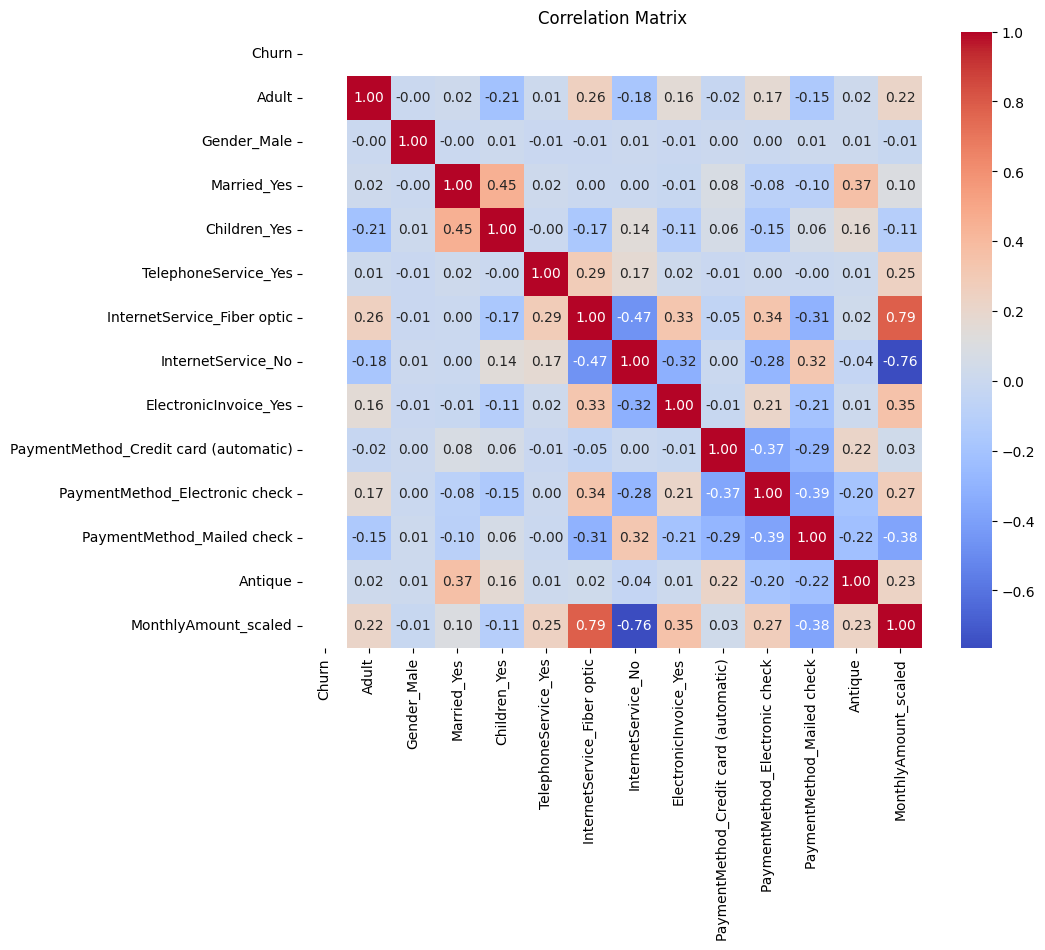

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df4.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()